In [ ]:
from utils import * 
import subprocess
import json 
import glob
from msa import msa_main
from files.rnafold import RNAFoldOutput
import shutil
from ppi import * 

%load_ext autoreload 
%autoreload 2

# Because of the signal peptide, I don't think this would be a protein that exists in the membrane of a viral-like envelope. 
# It must be using host peptidase/secretion machinery, which implies it ends up in the host cell membrane.

In [135]:
CLUSTER_ID_TO_GENE_ID_MAP = pd.DataFrame.from_dict(json.load(open('../data/genes/clusters.json', 'r')), orient='index', columns=['cluster_id']).reset_index(names='gene_id')
CLUSTER_ID_TO_GENE_ID_MAP = {cluster_id:df.gene_id.tolist() for cluster_id, df in CLUSTER_ID_TO_GENE_ID_MAP.groupby('cluster_id')}

In [64]:
tmhmm_file = TMHMMFile.from_file('../data/genes/tmhmm/genes.txt')
tmhmm_df = tmhmm_file.to_df()

INTERPROSCAN_FIELDS = ['gene_id', 'checksum', 'length', 'analysis', 'signature_accession', 'signature_description', 'annotation_start','annotation_stop', 'annotation_e_value', 'annotation_status', 'date', 'interpro_accession', 'interpro_description', 'go_terms', 'pathways']
annot_df = pd.read_csv('../data/genes/interproscan/genes.tsv', sep='\t', header=None, names=INTERPROSCAN_FIELDS)

In [ ]:
# Dalian_Groundwater_SRR22387926_scaffold_135972 is in the same sample as bz_2

In [3]:
# Load in contigs downloaded from ggKbase for use in ORF extension. 
GGKBASE_DIR = '../data/genes/ggkbase/'
contigs = dict()
for path in glob.glob(os.path.join(GGKBASE_DIR, 'contigs', '*')):
    contigs[os.path.basename(path).replace('.fasta', '')] = FASTAFile.from_file(path).seqs[0]
print('Loaded', len(contigs), 'contigs from', GGKBASE_DIR)

Loaded 8 contigs from ../data/genes/ggkbase/


In [ ]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))

SEQ_TO_GENE_ID_MAP = genes_df.reset_index(names='gene_id').set_index('seq').gene_id.to_dict()
SEQ_TO_CLUSTER_ID_MAP = genes_df.set_index('seq').cluster_id.to_dict() # Do this before filtering out all non-cluster_20. 

genes_df = genes_df[(genes_df.cluster_id == 20)].copy()
genes_df['gc_content'] = genes_df.nt_seq.apply(get_gc_content)

FASTAFile.from_df(genes_df).write('../data/genes/cluster_20.faa')
if not os.path.exists('../data/genes/cluster_20.afa'):
    subprocess.run('muscle -align ../data/genes/cluster_20.faa -output ../data/genes/cluster_20.afa', shell=True, check=True)

FASTAFile.from_df(genes_df.drop(columns=['seq']).rename(columns={'nt_seq':'seq'})).write('../data/genes/cluster_20.fna')
if not os.path.exists('../data/genes/cluster_20.afn'):
    subprocess.run('muscle -align ../data/genes/cluster_20.fna -output ../data/genes/cluster_20.afn', shell=True, check=True)

for row in genes_df.itertuples():
    print(f'{row.Index} ({row.start}-{row.stop}) {row.gc_content * 100:.1f}% GC')

print('\nMinimum cluster_20 gene length:', genes_df.seq.apply(len).min())
print('Maximum cluster_20 gene length:', genes_df.seq.apply(len).max())

GENOME_ID_TO_GENE_ID_MAP = genes_df.reset_index(names='gene_id').set_index('genome_id').gene_id.to_dict()
GENOME_ID_TO_GENOME_MAP = {genome_id:FASTAFile.from_file(f'../data/genomes/{genome_id}.fasta').seqs[0] for genome_id in genes_df.genome_id.unique()}

orfm.bz_0.1_114 (10257-10553) 37.8% GC
orfm.bz_4.1_121 (10937-11230) 37.5% GC
orfm.bz_11.1_116 (11033-11324) 37.8% GC

Minimum cluster_20 gene length: 96
Maximum cluster_20 gene length: 97


In [5]:
# The structure for cluster_20 proteins is extremely weak, so I ran another BLAST search against ggKbase 
# in an attempt to find homologs. I then filtered the hits by manual inspection and refinement of the MSA. 
GGKBASE_DIR = '../data/genes/ggkbase/'

nt_seqs = dict(zip(FASTAFile.from_file(os.path.join(GGKBASE_DIR, 'cluster_20.fna')).ids, FASTAFile.from_file(os.path.join(GGKBASE_DIR, 'cluster_20.fna')).seqs))

ggkbase_df = FASTAFile.from_file(os.path.join(GGKBASE_DIR, 'cluster_20.faa')).to_df()
ggkbase_df['nt_seq'] = ggkbase_df.index.map(nt_seqs)
ggkbase_df.index = [gene_id.split('|')[0] for gene_id in ggkbase_df.index] # Clean up the ggKbase gene IDs.
ggkbase_df['seq'] = ggkbase_df.seq.str.replace('*', '', regex=False)
ggkbase_df['contig_id'] = ['_'.join(gene_id.split('_')[:-1]) for gene_id in ggkbase_df.index]
ggkbase_df['start'] = ggkbase_df.description.apply(lambda description : int(description.split('#')[1].strip())) # Convert to zero-indexed for my sanity. 
ggkbase_df['stop'] = ggkbase_df.description.apply(lambda description : int(description.split('#')[2].strip()))
ggkbase_df['strand'] = ggkbase_df.description.apply(lambda description : int(description.split('#')[3].strip())).replace({-1:'-', 1:'+'})
ggkbase_df['length'] = ggkbase_df.seq.apply(len)

print('Number of unique contigs:', ggkbase_df.contig_id.nunique())

# Replace the shorter sequence corresponding to orfm.bz_11.1_116 with the one in genes_df. 
ggkbase_df.loc['SR-VP_9_9_2021_56_4A_0_95m_scaffold_3886_3', 'seq'] = genes_df.loc['orfm.bz_11.1_116', 'seq']
ggkbase_df.loc['SR-VP_9_9_2021_56_4A_0_95m_scaffold_3886_3', 'nt_seq'] = genes_df.loc['orfm.bz_11.1_116', 'nt_seq']
ggkbase_df.loc['SR-VP_9_9_2021_56_4A_0_95m_scaffold_3886_3', 'stop'] += (12 * 3)

filters = dict()
filters['subject_too_long'] = ggkbase_df.seq.apply(len) > 110
filters['duplicate_gene_id'] = ggkbase_df.index.duplicated(keep='first')
filters['duplicate_nt_sequence'] = ggkbase_df.nt_seq.duplicated(keep='first') & ~ggkbase_df.nt_seq.isnull()
filters['weak_alignment'] = ggkbase_df.index == 'SR2-18-Sp2_coassembly_scaffold_597830_2'
filters['no_nt_seq'] = ggkbase_df.nt_seq.isnull()

ggkbase_df = apply_filters(filters, ggkbase_df)
print('Number of ggKbase hits remaining after filtering:', len(ggkbase_df), end='\n\n')
assert np.all(genes_df.seq.isin(ggkbase_df.seq.values)), 'Some of the sequences in genes_df are not present in the BLAST results.'


for row in ggkbase_df.itertuples():
    gene_id =  genes_df[genes_df.seq == row.seq].index[0] if (row.seq in genes_df.seq.values) else None
    print(row.Index, f'({gene_id})' if (gene_id is not None) else '')
    
# print('\n' + '\n'.join(ggkbase_df.contig_id))
# It seems as though sequence identity extends to the nucleotide level, as de-duplicating based on nucleotide sequence removes most of the sequences.


Number of unique contigs: 62
apply_filters: 19 entries removed by subject_too_long.
apply_filters: 77 entries removed by duplicate_gene_id.
apply_filters: 113 entries removed by duplicate_nt_sequence.
apply_filters: 1 entries removed by weak_alignment.
apply_filters: 9 entries removed by no_nt_seq.
Number of ggKbase hits remaining after filtering: 8

SR-VP_26_10_2019_1_100cm_scaffold_2098_23 (orfm.bz_0.1_114)
SR-VP_9_9_2021_31_2B_1_5m_scaffold_23596_3 
SR-VP_9_9_2021_56_4A_0_95m_scaffold_3886_3 (orfm.bz_11.1_116)
SR-VP_9_9_2021_59_4A_0_85m_scaffold_34976_2 
SR-VP_11_27_2022_S1_60cm_scaffold_16350_2 
Dalian_Groundwater_SRR22387926_scaffold_135972_3 
Nantong_Groundwater_SRR22387873_scaffold_1350_25 (orfm.bz_4.1_121)
SR-VP_07_25_2022_A1_70cm_scaffold_29863_3 


In [6]:
# Based on the data, the possibilities seem to be:
#   (1) The proteins which are longer at the N-terminus are erroneously extendeded. 
#   (2) The proteins which are shorter at the N-terminus are erroneously truncated. 
#   (3) The ORF boundaries are all correct, and only some of the proteins have the N-terminal domain. 

# It should be noted that many of the aligned proteins are from SR-VP, and may be closely related. Conservation 
# Should perhaps be taken with a grain of salt. For example, orfm.bz_0.1_114 and SR-VP_11_27_2022_S1_60cm_scaffold_16350_2 seem to be
# identical, but Prodigal selected a different start site. This is also true for orfm.bz_11.1_116 and SR-VP_9_9_2021_31_2B_1_5m_scaffold_23596_3.

# I don't think there is enough information to use conservation as a good signal for if the N-terminal helix is real, particularly because 
# signal peptides are not conserved at the sequence level [Auclair et. al. 2011]. Instead, I am going to look at potential extensions 
# and truncations of each sequence. 

# **If needed, I can map reads to the start codons as a potential way to evaluate conservation, but this might be a headache.

In [7]:
# It seems as though many of the longer ORFs have alternate start sites which would truncate the ORF to around 80-90 residues.
# However, most of the longer ones do not have an ATG start codon that would shift the length to ~60 (with the 
# possible exception of SR-VP_9_9_2021_59_4A_0_85m_scaffold_34976_2). This suggests that if there was an error in ORF boundary
# prediction, it is more likely that the 60 residue genes were N-terminally truncated.

max_truncation_length = 40 # Only consider start codons that would shorten the sequence by < max_truncation_length amino acids. 

for row in ggkbase_df.itertuples():
    nt_seq = row.nt_seq
    length = len(row.seq)
    assert (len(nt_seq) % 3) == 0, 'Length of the nucleotide sequence should be a multiple of three.'

    codons = np.array([nt_seq[i:i+3] for i in range(0, len(nt_seq), 3)])[:max_truncation_length] # Get all potential alternate starts. 
    start_codon_idxs = np.where(np.isin(codons, START_CODONS))[0][1:].tolist()

    start_codons = codons[start_codon_idxs].tolist()
    start_codons = list(zip(start_codon_idxs, start_codons))
    print(row.Index, f'({length} aa):\t', start_codons)


SR-VP_26_10_2019_1_100cm_scaffold_2098_23 (97 aa):	 [(7, 'ATG'), (9, 'ATG'), (19, 'TTG')]
SR-VP_9_9_2021_31_2B_1_5m_scaffold_23596_3 (84 aa):	 [(7, 'TTG'), (32, 'TTG')]
SR-VP_9_9_2021_56_4A_0_95m_scaffold_3886_3 (96 aa):	 [(12, 'ATG'), (19, 'TTG')]
SR-VP_9_9_2021_59_4A_0_85m_scaffold_34976_2 (96 aa):	 [(3, 'ATG'), (6, 'ATG'), (24, 'ATG')]
SR-VP_11_27_2022_S1_60cm_scaffold_16350_2 (88 aa):	 [(10, 'TTG')]
Dalian_Groundwater_SRR22387926_scaffold_135972_3 (62 aa):	 [(10, 'TTG'), (19, 'TTG')]
Nantong_Groundwater_SRR22387873_scaffold_1350_25 (96 aa):	 [(1, 'GTG'), (15, 'ATG'), (18, 'TTG')]
SR-VP_07_25_2022_A1_70cm_scaffold_29863_3 (61 aa):	 [(13, 'TTG'), (38, 'GTG')]


In [8]:
def extend(start:int, stop:int, strand:int, extension_length:int=30, contig:str=None, frame_shift:int=0):
    '''
    Extend the gene between start and stop at the N-terminus by the specified number amino acids, ignoring any in-frame stop codons.

    :param start: The one-indexed (inclusive) starting coordinate of the ORF. 
    :param stop: The one-indexed (inclusive) ending coordinate of the ORF.
    :param strand: The strand of the ORF, either - or +.
    :param contig: The contig on which the gene is found.
    :param extension_length: The number of amino acids to extend the gene by. 
    :param frame_shift: If not zero, this specifies how much to shift the reading frame when translating the extended N-terminus. 
    :returns:
    '''

    if strand == '-':
        old_start, old_stop = start, stop
        start = (len(contig) - old_stop) + 1
        stop = (len(contig) - old_start) + 1
        contig = reverse_complement(contig)

    assert contig[start - 1:start - 1 + 3] in START_CODONS, f'extend: Expected a valid start codon, but got {contig[start - 1:start - 1 + 3]}.'
    assert contig[stop - 3:stop] in STOP_CODONS, f'extend: Expected a valid stop codon, but got {contig[stop - 3:stop]}.'

    ext_stop = (start - 1) - frame_shift # Extended region will end at the start position.
    ext_start = ext_stop - 3 * extension_length
    assert ext_start > 0,  f'extend: Extension start coordinate cannot be negative, so {ext_start} is invalid.'
    ext = str(Seq(contig[ext_start:ext_stop]).translate(to_stop=False))
    codons = [contig[ext_start:ext_stop][i:i + 3] for i in range(0, ext_stop - ext_start, 3)]
    return ext, codons


for row in ggkbase_df.sort_values('contig_id').itertuples():
    if row.contig_id not in contigs:
        continue 

    ext, codons = extend(row.start, row.stop, row.strand, contig=contigs[row.contig_id], frame_shift=0)
    has_start_codon = np.any(np.isin(['ATG'], codons))

    # Get the potential start codons which are not followed by a stop codon (so possible valid extensions)
    stop_codon_idxs = np.where(np.isin(codons, STOP_CODONS))[0]
    start_codon_idxs = np.where(np.isin(codons, START_CODONS))[0]
    start_codon_idxs = start_codon_idxs[start_codon_idxs > stop_codon_idxs.max()]

    if len(start_codon_idxs) > 0:
        seq_extended = ext[start_codon_idxs.min():] + row.seq
        ggkbase_df.loc[row.Index, 'seq_extended'] = seq_extended
        print(f'Extended {row.Index} ({len(row.seq)} aa to {len(seq_extended)} aa)\t{seq_extended}')
    else:
        ggkbase_df.loc[row.Index, 'seq_extended'] = row.seq
        print(f'No extension for {row.Index} ({len(row.seq)} aa)')

    # print(row.Index, f'({len(row.seq)} aa)\tHas start codon? {has_start_codon}')
    # print(ext, row.seq, end='\n\n')

# It seems unlikely that the 61-residue ones cannot be extended (I tried all three frames). However, the proteins in the 88-residue
# range can be reasonably extended. If these is indeed a signal peptide, an N-terminal extension would add a run of positive residues that
# might make the signal peptide prediction more robust. 

# See https://pmc.ncbi.nlm.nih.gov/articles/PMC2323981/ for information on archaeal signal peptides.
# Betazoid signal peptides should resemble those of archaea (as they would be using host secretion machinery.)
    

No extension for Dalian_Groundwater_SRR22387926_scaffold_135972_3 (62 aa)
No extension for Nantong_Groundwater_SRR22387873_scaffold_1350_25 (96 aa)
No extension for SR-VP_07_25_2022_A1_70cm_scaffold_29863_3 (61 aa)
Extended SR-VP_11_27_2022_S1_60cm_scaffold_16350_2 (88 aa to 97 aa)	MSNKNKAMVMLLIVAGVFALSASAVSATSCTDAGDFVGICNTVIGIANGTLAVISILFTGNNASIIIEAALIVTIVGAILDLSRGKSSWLRSKFERV
No extension for SR-VP_26_10_2019_1_100cm_scaffold_2098_23 (97 aa)
Extended SR-VP_9_9_2021_31_2B_1_5m_scaffold_23596_3 (84 aa to 96 aa)	MITSKKILFSTIMIVSIAFLTLPATATVCSDAGSFNSTCVTITDLGKGIIAVFSVLVTGDNAGVLITTAITIAIVVAVFDLSRGKESYIGRHFRRM
No extension for SR-VP_9_9_2021_56_4A_0_95m_scaffold_3886_3 (96 aa)
No extension for SR-VP_9_9_2021_59_4A_0_85m_scaffold_34976_2 (96 aa)


In [9]:
# Based on the analysis above, the most likely scenario seems to be that some of the proteins are N-terminally truncated, 
# and that the ones with an N-terminal region have a signal peptide which is not present in other Betazoids. This would mean that the
# signal peptide is not part of the final structure, which might affect hypotheses about its function. 

# Write the de-duplicated and N-terminally extended sequences (with the ggKbase ID) to FASTA files.
FASTAFile.from_df(ggkbase_df.assign(seq=ggkbase_df.seq_extended).drop_duplicates('seq')).write('../data/genes/cluster_20_extended.faa')

tmhmm_df = TMHMMFile.from_file('../data/genes/tmhmm/cluster_20_extended.txt').to_df()
deep_tmhmm_df = DeepTMHMMFile.from_file('../data/genes/deep_tmhmm/cluster_20_extended.gff3').to_df()

SIGNALP_FIELDS = ['gene_id', 'prediction', 'other', 'sp_sec_spi', 'lipo_sec_spii', 'tat_tat_spi', 'tatlipo_tat_spii', 'pilin_sec_spiii', 'cleavage_site_position']
signalp_df = pd.read_csv('../data/genes/signalp/cluster_20_extended/prediction_results.txt', sep='\t', comment='#', names=SIGNALP_FIELDS)

print('DeepTMHMM predictions:')
for gene_id, df in deep_tmhmm_df.groupby('gene_id'):
    num_tmhs = (df.location == 'TMhelix').sum()
    has_sp = 'signal' in df.location.values
    print(f'{gene_id}: {num_tmhs} TMHs,', 'signal peptide' if has_sp else 'no signal peptide')

print('\nTMHMM predictions:')
for gene_id, df in tmhmm_df.groupby('gene_id'):
    num_tmhs = (df.location == 'TMhelix').sum()
    has_sp = 'signal' in df.location.values
    print(f'{gene_id}: {num_tmhs} TMHs,')

print('\nSignalP predictions:')
for row in signalp_df.itertuples():
    probability = [getattr(row, field) for field in [ 'other', 'sp_sec_spi', 'lipo_sec_spii', 'tat_tat_spi', 'tatlipo_tat_spii', 'pilin_sec_spiii']]
    probability = max(probability)
    print(f'{row.gene_id}: {probability * 100:.2f}% {row.prediction}')



DeepTMHMM predictions:
Dalian_Groundwater_SRR22387926_scaffold_135972_3: 1 TMHs, no signal peptide
Nantong_Groundwater_SRR22387873_scaffold_1350_25: 1 TMHs, signal peptide
SR-VP_07_25_2022_A1_70cm_scaffold_29863_3: 1 TMHs, no signal peptide
SR-VP_26_10_2019_1_100cm_scaffold_2098_23: 1 TMHs, signal peptide
SR-VP_9_9_2021_31_2B_1_5m_scaffold_23596_3: 1 TMHs, signal peptide
SR-VP_9_9_2021_59_4A_0_85m_scaffold_34976_2: 1 TMHs, signal peptide

TMHMM predictions:
Dalian_Groundwater_SRR22387926_scaffold_135972_3: 1 TMHs,
Nantong_Groundwater_SRR22387873_scaffold_1350_25: 2 TMHs,
SR-VP_07_25_2022_A1_70cm_scaffold_29863_3: 2 TMHs,
SR-VP_26_10_2019_1_100cm_scaffold_2098_23: 3 TMHs,
SR-VP_9_9_2021_31_2B_1_5m_scaffold_23596_3: 2 TMHs,
SR-VP_9_9_2021_59_4A_0_85m_scaffold_34976_2: 2 TMHs,

SignalP predictions:
SR-VP_26_10_2019_1_100cm_scaffold_2098_23: 83.45% SP
SR-VP_9_9_2021_31_2B_1_5m_scaffold_23596_3: 94.28% SP
SR-VP_9_9_2021_59_4A_0_85m_scaffold_34976_2: 93.73% SP
Dalian_Groundwater_SRR22387926_

In [50]:
ggkbase_gene_id_to_gene_id_map = dict()
ggkbase_gene_id_to_gene_id_map['SR-VP_9_9_2021_31_2B_1_5m_scaffold_23596_3'] = 'orfm.bz_11.1_116'
ggkbase_gene_id_to_gene_id_map['SR-VP_9_9_2021_56_4A_0_95m_scaffold_3886_3'] = 'orfm.bz_11.1_116'
ggkbase_gene_id_to_gene_id_map['SR-VP_11_27_2022_S1_60cm_scaffold_16350_2'] = 'orfm.bz_0.1_114'
ggkbase_gene_id_to_gene_id_map['SR-VP_26_10_2019_1_100cm_scaffold_2098_23'] = 'orfm.bz_0.1_114'
ggkbase_gene_id_to_gene_id_map['Nantong_Groundwater_SRR22387873_scaffold_1350_25'] = 'orfm.bz_4.1_121'

processed_seqs = FASTAFile.from_file('../data/genes/signalp/cluster_20_extended/processed_entries.fasta').to_df().seq.to_dict()

# Write the processed sequences to a FASTA file for alignment. 
database_df = ggkbase_df.copy()
database_df = database_df.drop_duplicates('seq_extended') # Remove the sequences that are identical (just different at the N-terminus.)
database_df['seq_processed'] = database_df.index.map(processed_seqs)
database_df['seq_processed'] = np.where(database_df.seq_processed.isnull(), database_df.seq, database_df.seq_processed)
database_df['length_processed'] = database_df.seq_processed.apply(len)
database_df.index = database_df.index.map(lambda ggkbase_gene_id : ggkbase_gene_id_to_gene_id_map.get(ggkbase_gene_id, ggkbase_gene_id)) # Replace the ggKbase gene IDs where applicable.

database_path = '../data/genes/cluster_20_processed_database.faa'

FASTAFile.from_df(database_df.assign(seq=database_df.seq_processed, description='')).write(database_path)
msa_main(database_path, query_gene_ids=genes_df.index.tolist(), fmt='afa', name=f'cluster_20_processed', output_dir='../data/genes/muscle', min_coverage=0.9)

# Also generate MSAs in the correct format for AlphaFold.
msa_paths = msa_main(database_path, query_gene_ids=genes_df.index.tolist(), fmt='a3m', name=f'cluster_20_processed', database_dir='../data/genes/mmseqs/db/', output_dir='../data/genes/mmseqs', min_coverage=0.9)

# Add the processed seqs to the genes_df. 
genes_df['seq_processed'] = genes_df.index.map(database_df.seq_processed)

msa_dereplicate: min_coverage = 0.9
msa_dereplicate: min_seq_identity = 0.95
msa_dereplicate: coverage_mode = 5
msa_dereplicate: 6 representative sequences when clustered at 0.95 minimum identity.
msa_build_afa: muscle -align /home/prichter/Documents/banfield/betazoid/data/genes/muscle/cluster_20_processed_database_reps.faa -output /home/prichter/Documents/banfield/betazoid/data/genes/muscle/cluster_20_processed.afa
msa_build_afa: clipkit /home/prichter/Documents/banfield/betazoid/data/genes/muscle/cluster_20_processed.afa -o /home/prichter/Documents/banfield/betazoid/data/genes/muscle/cluster_20_processed.trimmed.afa -g 0.8 --log
msa_dereplicate: min_coverage = 0.9
msa_dereplicate: min_seq_identity = 0.95
msa_dereplicate: coverage_mode = 5
msa_dereplicate: 6 representative sequences when clustered at 0.95 minimum identity.
msa_build_a3m: num_iterations = 1
msa_build_a3m: sensitivity = 9.5
msa_build_a3m: mmseqs createdb ../data/genes/mmseqs/cluster_20_processed_database_reps.faa ../dat

In [11]:
# The preliminary protein-protein interaction screen did not indicate any contacts, but it seems as though providing an MSA substantially improves structure prediction.
# I think it is worth re-trying with MSAs for all proteins that have an MSA. Also, the results may be different with the signal peptide cleaved, particularly
# because it seems likely that if any region of the protein participates in PPI, it is the N-terminal helix following the SP.


msas = {os.path.basename(path.replace('.a3m', '')):open(path, 'r').read() for path in glob.glob('../data/genes/mmseqs/*a3m')} # Load all MSAs.

supported_gene_ids = np.loadtxt('analysis-1-cluster-supported_gene_ids.txt', dtype=str)

df = pd.read_csv('../data/genes/genes.csv', index_col=0).loc[supported_gene_ids]
df['gene_id'] = df.index.values 
df['seq_processed'] = df.gene_id.map(processed_seqs)
df['seq_processed'] = np.where(df.seq_processed.isnull(), df.seq, df.seq_processed)

pairs = list()
for gene_id in genes_df.index:
    row = df.loc[gene_id].to_dict()
    pairs += [(row, row_) for row_ in df[df.genome_id == get_genome_id(gene_id)].to_dict(orient='records')]


ALPHAFOLD_INPUT_DIR = f'../data/genes/alphafold/af_input/ppi-cluster_20'
ALPHAFOLD_OUTPUT_DIR = f'../data/genes/alphafold/af_output/ppi-cluster_20' 

ALPHAFOLD_PARAMS = dict()
ALPHAFOLD_PARAMS['--num_diffusion_samples'] = 1 # Number of diffusion samples to generate, 5 by default. 
ALPHAFOLD_PARAMS['--num_recycles'] = 5 # Number of recycles to use during inference (refinement steps). 10 by default, dropped here to mitigate runtime. 
os.makedirs(ALPHAFOLD_INPUT_DIR, exist_ok=True)

names = list()

for pair in pairs:

    gene_ids = [pair[0]['gene_id'], pair[1]['gene_id']]
    seqs = [pair[0]['seq_processed'], pair[1]['seq_processed']]

    name = '-'.join(gene_ids)
    names.append(name)

    file = AlphaFoldInputFile(name, dialect='alphafold3', num_seeds=5, version=2)

    for gene_id, seq in zip(gene_ids, seqs):
        if gene_id in msas:
            paired_msa, unpaired_msa = '', msas[gene_id]
        else: # I think these both need to be None
            paired_msa, unpaired_msa = None, None

        file.add_seq(seq, paired_msa=paired_msa, unpaired_msa=unpaired_msa)

    file.write(os.path.join(ALPHAFOLD_INPUT_DIR, f'{name}.json'))

print('Number of co-folds:', len(names), end='\n\n')

cmd = [f'run_alphafold3 --input_dir=/root/af_input/{os.path.basename(ALPHAFOLD_INPUT_DIR)}/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir={ALPHAFOLD_OUTPUT_DIR}']
cmd += [f'{param} {value}' for param, value in ALPHAFOLD_PARAMS.items()]
cmd = ' '.join(cmd)
cmd = f'sbatch --partition gpu --gpus 1 --wrap "{cmd}"'
print(cmd) 


Number of co-folds: 149

sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --input_dir=/root/af_input/ppi-cluster_20/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=../data/genes/alphafold/af_output/ppi-cluster_20 --num_diffusion_samples 1 --num_recycles 5"


In [206]:
# The DeepTMHMM transmembrane predictions seem to make more sense than those from TMHMM. The number of TMHs is consistent across homologs, 
# and the topology (with the positive C-terminus inside) is both consistent and expected. The helix coordinates also align with the 
# predicted AlphaFold structure, as well as the hydrophobicity plot. 

deep_tmhmm_df = DeepTMHMMFile.from_file('../data/genes/deep_tmhmm/cluster_20_extended.gff3').to_df()

deep_tmhmm_df['gene_id'] = deep_tmhmm_df.gene_id.map(ggkbase_gene_id_to_gene_id_map)
deep_tmhmm_df = deep_tmhmm_df[~deep_tmhmm_df.gene_id.isnull()].copy()
deep_tmhmm_df['length_diff'] = deep_tmhmm_df.gene_id.map(deep_tmhmm_df[deep_tmhmm_df.location == 'signal'].set_index('gene_id').end)
deep_tmhmm_df['start_processed'] = deep_tmhmm_df.start - deep_tmhmm_df.length_diff
deep_tmhmm_df['end_processed'] = deep_tmhmm_df.end - deep_tmhmm_df.length_diff

print('TMH indices (based on the sequence with the SP removed)')
for row in deep_tmhmm_df[deep_tmhmm_df.location == 'TMhelix'].itertuples():
    print(row.gene_id, f'TMH from {row.start_processed}-{row.end_processed}')

# for row in deep_tmhmm_df[deep_tmhmm_df.location == 'outside'].itertuples():
#     start, end = row.start_processed, row.end_processed
#     seq = database_df.loc[row.gene_id].seq_processed[start:end]
#     seq = ''.join([REDUCED_ALPHABET.get(aa) for aa in seq])
#     print(row.gene_id, f'outside region from {start}-{end}\t', seq)

# Apparently the positively-charged C terminus might just help with membrane orientation. 


TMH indices (based on the sequence with the SP removed)
orfm.bz_0.1_114 TMH from 38-55
orfm.bz_11.1_116 TMH from 36-53
orfm.bz_4.1_121 TMH from 36-56


In [114]:
# get_pairwise_alignments(genes_df.seq_processed, metric='identities', normalize=True)

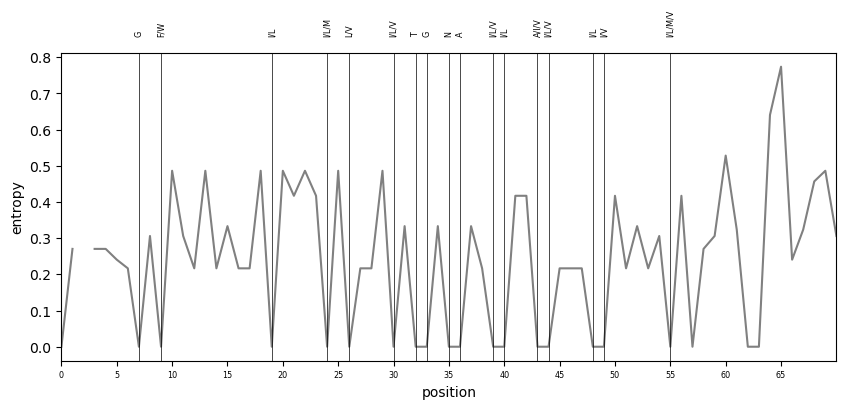

In [14]:
msa = MSAFile.from_file('../data/genes/muscle/cluster_20_processed.afa') # Load the untrimmed alignment.
# msa = MSAFile.from_file('../data/genes/cluster_20.afn') # Load the untrimmed alignment.
# plot_hydrophobicity(msa, x_max=70)
# msa.show()
def plot_entropy(msa:MSAFile, max_entropy=0.2, x_min=20, x_max=70, ax:plt.Axes=None, color:str='gray', alphabet:dict=None, annotate:bool=False):

    entropy = msa.get_entropy(alphabet=alphabet, max_gap_fraction=0.8)

    ax.plot(np.arange(len(entropy)), entropy, color=color)

    if annotate:
        conserved_idxs = np.where((entropy < max_entropy) & (~np.isnan(entropy)))[0] 
        # conserved_idxs = [idx for idx in conserved_idxs if (msa.gap_symbol not in msa.to_array().T[idx])] # Remove indices that look conserved but have a gap. 
        conserved_aas = [np.unique(msa.to_array().T[idx]) for idx in conserved_idxs]

        for idx, aas in zip(conserved_idxs, conserved_aas):
            if MSAFile.gap_symbol in aas:
                continue 
            
            if (idx > x_max) or (idx < x_min):
                continue
            ax.text(idx, ax.get_ylim()[-1] + 0.05, '/'.join(aas), ha='center', fontsize='xx-small', rotation=90)
            ax.axvline(idx, color='black', lw=0.5)

    x_ticks = np.arange(x_min, x_max, 5)
    ax.set_xticks(x_ticks, labels=x_ticks, fontsize='xx-small')
    ax.set_xlim(xmin=x_min, xmax=x_max)
    ax.set_ylabel('entropy')
    ax.set_xlabel('position')

x_min, x_max = 0,70 
fig, ax = plt.subplots(figsize=(10, 4))

plot_entropy(msa, ax=ax, x_min=x_min, x_max=x_max, alphabet=REDUCED_ALPHABET, annotate=True)




In [207]:

# if not os.path.exists('analysis-1-cluster_20-contacts.csv'): # These AlphaFold jobs were created using the processed forms of the proteins.
#     contacts_df = list()
#     for path in tqdm(glob.glob('../data/genes/alphafold/af_output/ppi-cluster_20/*'), desc='Loading contact data.'):
#         output = AlphaFoldOutput(path, version=4)
#         contacts_df.append(get_contacts(output, min_contact_prob=0.1))
#     contacts_df = pd.concat(contacts_df)
#     contacts_df.to_csv('analysis-1-cluster_20-contacts.csv', index=False)
# else:
#     contacts_df = pd.read_csv('analysis-1-cluster_20-contacts.csv')


# def get_contact_id(row):
#     '''Construct a contact_id from a contact_df entry. These IDs are of the form {node_type}:{position}.'''
#     residue_num_0 = int(row.residue_num_0) if hasattr(row, 'residue_num_0') else 0 
#     residue_num_1 = int(row.residue_num_1) if hasattr(row, 'residue_num_1') else 0 
#     contact_id = sorted([f'{int(row.cluster_id_0)}:{residue_num_0}', f'{int(row.cluster_id_1)}:{residue_num_1}'])
#     # contact_id = sorted([f'{row.chain_id_0}:{row.residue_num_0}', f'{row.chain_id_1}:{row.residue_num_1}'])
#     return '-'.join(contact_id)

# # Add the N-terminally truncated sequences to the maps so that this doesn't break. 
# for row in genes_df.itertuples():
#     SEQ_TO_CLUSTER_ID_MAP[row.seq_processed] = 20 
#     SEQ_TO_GENE_ID_MAP[row.seq_processed] = row.Index 

# contacts_df['gene_id_0'] = contacts_df.seq_0.map(genes_df.reset_index(names='gene_id').set_index('seq_processed').gene_id)
# contacts_df['gene_id_1'] = contacts_df.seq_1.map(SEQ_TO_GENE_ID_MAP)
# contacts_df['cluster_id_0'] = contacts_df.seq_0.map(SEQ_TO_CLUSTER_ID_MAP)
# contacts_df['cluster_id_1'] = contacts_df.seq_1.map(SEQ_TO_CLUSTER_ID_MAP) # .astype(int) # seq_1 is always then non-cluster_20 protein.
# contacts_df['contact_id'] = contacts_df.apply(get_contact_id, axis=1)
# contacts_df['genome_id'] = contacts_df.name.apply(get_genome_id)

# print('Number of tested PPI contact:', len(os.listdir('../data/genes/alphafold/af_output/ppi-cluster_20/')))
# print('Number of tested PPI contacts with any interaction:', contacts_df.name.nunique())

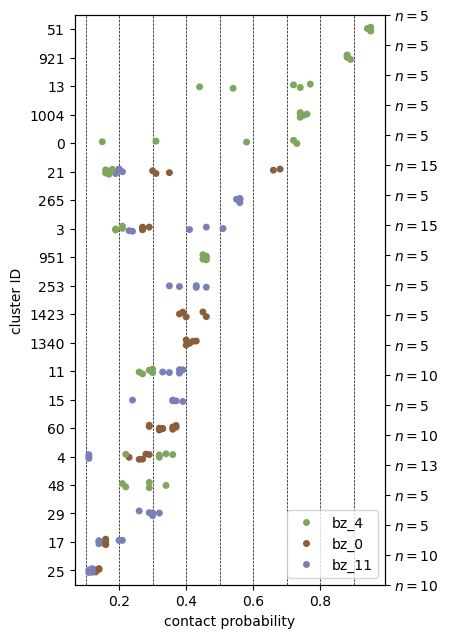

In [202]:

figure_df = contacts_df[contacts_df.contact_prob > 0].copy()
figure_df['num_genomes'] = figure_df.contact_id.map(contacts_df.groupby('contact_id').apply(lambda df : df.dropna().genome_id.nunique()))
# figure_df = figure_df[figure_df.num_genomes > 1].copy() # Keep interactions present in more than one genome.
figure_df['cluster_id'] = [row.cluster_id_0 if (row.cluster_id_0 != 20) else row.cluster_id_1 for row in figure_df.itertuples()]
figure_df['cluster_id'] = figure_df['cluster_id'].astype(int).astype(str)

figure_df = figure_df.sort_values('contact_prob', ascending=False).drop_duplicates(['name', 'model']) # Only keep the best contact from each set of proteins and model.
figure_df['num_models'] = figure_df.groupby('cluster_id').transform('size') # There should be no duplicate models at this point!
figure_df = figure_df[figure_df.num_models > 1].copy()

filter_ = figure_df.groupby('cluster_id', sort=False).apply(lambda df : np.any(df.contact_prob > 0.3))
cluster_ids = figure_df.cluster_id.unique()[filter_].tolist() + ['25', '17']
figure_df = figure_df[figure_df.cluster_id.isin(cluster_ids)].copy()

fig, ax = plt.subplots(figsize=(4, len(figure_df) * 0.05))

sns.stripplot(figure_df, y='cluster_id', x='contact_prob', hue='genome_id', palette=GENOME_ID_COLORS)
ax.set_ylabel('cluster ID')
ax.set_xlabel('contact probability')
ax.legend().set_title('')

num_models = figure_df.groupby('cluster_id', sort=False).size().values
num_models = [f'$n={n}$' for n in num_models][::-1] # Need to reverse the list to make the axes labels correct.
ax.twinx().set_yticks(np.arange(len(num_models)), labels=num_models)

for x in 0.1 * np.arange(1, 10):
    ax.axvline(x, ls='--', color='black', lw=0.5, zorder=-1)

plt.show()
# sns.stripplot(figure_df, y='cluster_id_1', x='contact_prob', hue='pae_less_than_10', palette='Grays')

In [ ]:
# cluster_21
# Has a really weak AlphaFold structure, but enough homologs that it might be worth trying to get a better one.

# cluster_11
# This is just a small helical protein shaped a bit like a hairpin, with reasonably high confidence. Probably won't 
# produce much better results with an alignment. All of the matches are to very similar small phage proteins with no function.

In [153]:
foldseek_search_df = pd.concat([pd.read_csv(path, sep='\t', names=FOLDSEEK_FIELDS).assign(path=path) for path in glob.glob('../data/genes/foldseek/genes*')])

filters = dict()
filters['low_tm_score'] = foldseek_search_df.alignment_tm_score < 0.5
filters['short_alignment'] = foldseek_search_df.alignment_length < 50

foldseek_search_df = apply_filters(filters, foldseek_search_df)

apply_filters: 263870 entries removed by low_tm_score.
apply_filters: 79859 entries removed by short_alignment.


In [205]:

cluster_id = 3
# cluster_id = 11
CLUSTER_ID_TO_GENE_ID_MAP[cluster_id]

['orfm.bz_0.1_191',
 'orfm.bz_1.1_155',
 'orfm.bz_2.1_22',
 'orfm.bz_3.1_43',
 'orfm.bz_4.1_184',
 'orfm.bz_5.1_151',
 'orfm.bz_7.1_194',
 'orfm.bz_8.1_215',
 'orfm.bz_9.1_34',
 'orfm.bz_10.1_15',
 'orfm.bz_11.1_23']

In [204]:
df = foldseek_search_df[foldseek_search_df.query_id.isin(CLUSTER_ID_TO_GENE_ID_MAP[cluster_id])].copy()
df.sort_values('alignment_tm_score')[['target_header', 'alignment_tm_score', 'query_length', 'alignment_length', 'target_length']].iloc[-50:]

,target_header,alignment_tm_score,query_length,alignment_length,target_length
221455,AF-K0TAX5-F1-model_v6 Uncharacterized protein,0.6101,96,93,79
221450,AF-A0A5N4EY33-F1-model_v6 Uncharacterized protein,0.6105,96,121,114
112661,A0A4D6DZV6,0.6113,96,87,72
112596,I6NSR1,0.6116,96,95,82
102910,AF-P53175-F1-model_v6 Putative uncharacterized...,0.6116,96,96,101
112631,A0A6J5NL27,0.6117,96,90,80
16908,6l2w-assembly1_B Crystal structure of a novel ...,0.6134,96,107,118
112761,A0A1S6L1N7,0.6137,96,105,254
112629,A0A8S5MWD0,0.6156,96,89,57
112650,A0A343RRL5,0.6163,96,88,54


In [17]:
# The results in the analysis-1-metat.ipynb notebook seems to indicate that there is something odd about the RNA encoding cluster_20 proteins. Specifically, it seems as though
# there is elevated GC content relative to the rest of the sequence, and lower free energy in the predicted secondary structure than expected based (controlling for length and 
# GC content). Furthermore, the BAM mapping indicates possible RNA circularization. 

#   (1) Does the RNA secondary structure have a consistent shape?
#   (2) Is elevated GC content a conserved feature of the cluster_20 proteins? Note that higher-GC genes will have lower free energy, as GC base pairing is stronger.
#   (3) Is there positive selection specifically forthe observed RNA features? Or is the elevated GC content and low free energy a consequence of selection
#       for specific amino acids?

for row in database_df.sort_index().itertuples():
    contig_gc_content = get_gc_content(contigs[row.contig_id])
    contig_length = len(contigs[row.contig_id])
    print(f'{row.Index} GC content: {get_gc_content(row.nt_seq):.2f} (contig GC content: {contig_gc_content:.2f}, contig length {contig_length})')

# It does seem as though the GC content is elevated in all cases, though still notably low in Dalian_Groundwater_SRR22387926_scaffold_135972_3.

Dalian_Groundwater_SRR22387926_scaffold_135972_3 GC content: 0.32 (contig GC content: 0.21, contig length 2035)
SR-VP_07_25_2022_A1_70cm_scaffold_29863_3 GC content: 0.40 (contig GC content: 0.31, contig length 4511)
SR-VP_9_9_2021_59_4A_0_85m_scaffold_34976_2 GC content: 0.40 (contig GC content: 0.25, contig length 2220)
orfm.bz_0.1_114 GC content: 0.37 (contig GC content: 0.26, contig length 18395)
orfm.bz_11.1_116 GC content: 0.40 (contig GC content: 0.30, contig length 3090)
orfm.bz_4.1_121 GC content: 0.37 (contig GC content: 0.21, contig length 19898)


In [18]:
def get_random_seqs_gc_content(nt_seq, n:int=100, seed:int=42):
    '''Generates n random nucleotide sequences of the same length and GC content as the input sequence. 
    
    :param nt_seq: The nucleotide sequence to use as reference.
    :param n: The number of sequences to generate. 
    '''
    if seed is not None:
        np.random.seed(seed)

    gc_content = get_gc_content(nt_seq)
    length = len(nt_seq)
    gc_count = int(length * gc_content)

    nt_seqs = list()
    for _ in range(n):
        # Randomly select a new set of bases with each iteration. 
        bases = np.random.choice(['G', 'C'], size=gc_count, replace=True).tolist()
        bases += np.random.choice(['A', 'T'], size=length - gc_count, replace=True).tolist()
        np.random.shuffle(bases) # Modifies inplace.
        nt_seqs.append(''.join(bases))

    return nt_seqs


# AMINO_ACID_TO_CODONS_MAP = {'A':['GCU','GCC','GCA','GCG'],'R':['CGU','CGC','CGA','CGG','AGA','AGG'],'N':['AAU','AAC'],'D':['GAU','GAC'],'C':['UGU','UGC'],'E':['GAA','GAG'],'Q':['CAA','CAG'],'G':['GGU','GGC','GGA','GGG'],'H':['CAU','CAC'],'I':['AUU','AUC','AUA'],'L':['UUA','UUG','CUU','CUC','CUA','CUG'],'K':['AAA','AAG'],'M':['AUG'],'F':['UUU','UUC'],'P':['CCU','CCC','CCA','CCG'],'S':['UCU','UCC','UCA','UCG','AGU','AGC'],'T':['ACU','ACC','ACA','ACG'],'W':['UGG'],'Y':['UAU','UAC'],'V':['GUU','GUC','GUA','GUG'],'*':['UAA','UAG','UGA']}
AMINO_ACID_TO_CODONS_MAP = {'A':['GCT','GCC','GCA','GCG'],'R':['CGT','CGC','CGA','CGG','AGA','AGG'],'N':['AAT','AAC'],'D':['GAT','GAC'],'C':['TGT','TGC'],'E':['GAA','GAG'],'Q':['CAA','CAG'],'G':['GGT','GGC','GGA','GGG'],'H':['CAT','CAC'],'I':['ATT','ATC','ATA'],'L':['TTA','TTG','CTT','CTC','CTA','CTG'],'K':['AAA','AAG'],'M':['ATG'],'F':['TTT','TTC'],'P':['CCT','CCC','CCA','CCG'],'S':['TCT','TCC','TCA','TCG','AGT','AGC'],'T':['ACT','ACC','ACA','ACG'],'W':['TGG'],'Y':['TAT','TAC'],'V':['GTT','GTC','GTA','GTG'],'*':['TAA','TAG','TGA']}
CODON_TO_AMINO_ACID_MAP = {codon:aa for aa, codons in AMINO_ACID_TO_CODONS_MAP.items() for codon in codons}



def get_codon_usage(nt_seqs):
    '''Get the codon usage frequencies for a particular set of genes'''
    counts = {codon:0 for codon in CODON_TO_AMINO_ACID_MAP.keys()}
    for nt_seq in nt_seqs:
        for codon, n in zip(*np.unique(get_codons(nt_seq), return_counts=True)):
            counts[str(codon)] += n

    df = pd.DataFrame.from_dict(counts, orient='index', columns=['count']).reset_index(names='codon')
    df['amino_acid'] = df.codon.map(CODON_TO_AMINO_ACID_MAP)
    df = df[df.amino_acid != '*'].copy()
    # df['frequency'] = df.groupby('amino_acid').transform(lambda df :print(df))
    df['total'] = df.groupby('amino_acid')['count'].transform('sum')
    df['frequency'] = df['count'] / df['total']
    df = df.fillna(0)
    return df.set_index('codon').frequency.to_dict()



def get_random_seqs_amino_acids(seq, n:int=1000, codon_usage:dict=dict(), seed:int=42):
    '''Generates n random nucleotide sequences constrained by the given amino acid sequence. If a codon_usage
    dictionary is provided, then codons are selected with a probability concordant with the background.
    '''
    if seed is not None:
        np.random.seed(seed)

    seqs = list()
    for aa in seq: # Iterate over each amino acid and store possible codons in a (len(seq), n)-dimensional array.
        codons = AMINO_ACID_TO_CODONS_MAP[aa] # Get all possible codons for the amino acid.
        frequencies = [codon_usage.get(codon, 1/len(codons)) for codon in codons]
        seqs.append(np.random.choice(codons, p=frequencies, size=n, replace=True))
    seqs = np.array(seqs).T
    seqs = [''.join(seq) for seq in seqs]
    return seqs


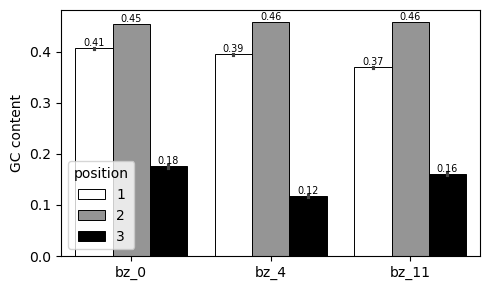

In [19]:
# Are there patterns in the position of GC enrichment? In other words, is GC1, GC2, or GC3 higher? This could indicate the nature of selection pressure on 
# the nucleotide sequencs; there is substantially more flexibility at the third codon position compared to the first or second. 
# If the RNA structure is being selected independently of the protein, there might be a strong effect at third codon positions, because synonymous substitutions 
# there can alter RNA structure without changing the protein.

def get_gc_content_by_position(genes_df:pd.DataFrame):
    ''''''
    df = list()
    for row in genes_df.itertuples():
        codons = [row.nt_seq[i:i + 3] for i in range(0, len(row.nt_seq), 3)]
        gc_counts = np.zeros(3)
        for codon in codons:
            gc_counts += np.isin(list(codon), ['G', 'C']).astype(int)
        df += [{'gene_id':row.Index, 'position':i + 1, 'gc_count':count, 'num_codons':len(codons)} for i, count in enumerate(gc_counts)]
    return pd.DataFrame(df) 


figure_df = list()

for row in genes_df.itertuples():
    codon_usage = get_codon_usage(FASTAFile.from_file(f'../data/genes/prodigal/{row.genome_id}.fna').seqs) # Just use the Prodigal genes to estimate codon usage.

    figure_df_ = get_gc_content_by_position(pd.DataFrame({'nt_seq':get_random_seqs_amino_acids(row.seq, n=500, codon_usage=codon_usage)}))
    figure_df_['genome_id'] = row.genome_id 
    figure_df.append(figure_df_)

figure_df = pd.concat(figure_df)
figure_df['gc_content'] = figure_df.gc_count / figure_df.num_codons

fig, ax = plt.subplots(figsize=(5, 3))
sns.barplot(figure_df, x='genome_id', y='gc_content', hue='position', palette='Grays', lw=0.7, edgecolor='black')
ax.set_ylabel('GC content')

for containers in ax.containers:
    ax.bar_label(containers, fmt='%.2f', fontsize='x-small')

ax.set_xlabel('')
fig.tight_layout()
plt.show()


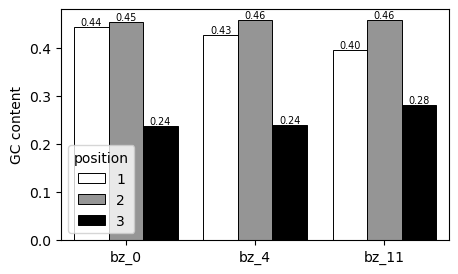

In [20]:
# Are there patterns in the position of GC enrichment? In other words, is GC1, GC2, or GC3 higher? This could indicate the nature of selection pressure on 
# the nucleotide sequencs; there is substantially more flexibility at the third codon position compared to the first or second. 
# If the RNA structure is being selected independently of the protein, there might be a strong effect at third codon positions, because synonymous substitutions 
# there can alter RNA structure without changing the protein.


figure_df = get_gc_content_by_position(genes_df)
figure_df['gc_content'] = figure_df.gc_count / figure_df.num_codons
figure_df['genome_id'] = [get_genome_id(gene_id) for gene_id in figure_df.gene_id]

fig, ax = plt.subplots(figsize=(5, 3))
sns.barplot(figure_df, x='genome_id', y='gc_content', hue='position', palette='Grays', lw=0.7, edgecolor='black')
ax.set_ylabel('GC content')

for containers in ax.containers:
    ax.bar_label(containers, fmt='%.2f', fontsize='x-small')
    
ax.set_xlabel('')
plt.show()

# The pattern in GC content positions doesn't seem to make a lot of sense, as I would expect GC1 and GC2 to be similar. Probably the best thing to do
# is compute the positional GC content for sequences  with the same amino acid sequence constraints. Maybe this odd pattern is just a result of amino acid-level selction.

In [21]:
n = 500
genome_id = 'bz_0'
gene_id = genes_df[genes_df.genome_id == genome_id].index[0]
nt_seq, seq = genes_df.loc[gene_id].nt_seq, genes_df.loc[gene_id].seq
codon_usage = get_codon_usage(FASTAFile.from_file(f'../data/genes/prodigal/{genome_id}.fna').seqs) # Just use the Prodigal genes to estimate codon usage.

RNAFOLD_DIR = '../data/genes/rnafold/'
RNAFOLD_CONTROL_DIR = os.path.join(RNAFOLD_DIR, 'control', genome_id)
os.makedirs(RNAFOLD_CONTROL_DIR, exist_ok=True) # Make a directory to store the control sequences. 


if os.path.exists(f'analysis-1-cluster_20-rnafold_{genome_id}.csv'):
    rnafold_df = pd.read_csv(f'analysis-1-cluster_20-rnafold_{genome_id}.csv', index_col=0)
else:

    rnafold_df = list()
    rnafold_df += [{'gc_content_control':True, 'codon_usage_control':False, 'amino_acid_control':False, 'nt_seq':nt_seq} for nt_seq in get_random_seqs_gc_content(nt_seq, n=n)]
    rnafold_df += [{'gc_content_control':False, 'codon_usage_control':False, 'amino_acid_control':True, 'nt_seq':nt_seq} for nt_seq in get_random_seqs_amino_acids(seq, n=n)]
    rnafold_df += [{'gc_content_control':False, 'codon_usage_control':True, 'amino_acid_control':True, 'nt_seq':nt_seq} for nt_seq in get_random_seqs_amino_acids(seq, n=n, codon_usage=codon_usage)]
    rnafold_df = pd.DataFrame(rnafold_df).assign(control=True)

    df = list()
    for row in tqdm(list(rnafold_df.itertuples()), desc='Running RNAFold analysis on random RNA sequences.'):
        output_path = os.path.abspath(os.path.join(RNAFOLD_CONTROL_DIR, f'{row.Index}.out'))

        if not os.path.exists(output_path):
            input = f'>{row.Index}\n{row.nt_seq}\n'
            with open(output_path, 'w') as f: # Run RNAFold, suppressing PS output. 
                subprocess.run(['RNAfold', '-p',  '--noPS', '-d2'], input=input, text=True, stdout=f, check=True, cwd=RNAFOLD_CONTROL_DIR)

        df += [RNAFoldOutput(os.path.join(RNAFOLD_CONTROL_DIR, str(row.Index))).get_data()]

    rnafold_df = pd.concat([rnafold_df, pd.DataFrame(df, index=rnafold_df.index)], axis=1) # Add the RNAFold output to the DataFrame.
    rnafold_df.to_csv(f'analysis-1-cluster_20-rnafold_{genome_id}.csv', index=True)

    # shutil.rmtree(RNAFOLD_CONTROL_DIR)
    

for row in tqdm(list(genes_df.itertuples()), desc='Running RNAFold analysis.'):
    name = f'{row.Index}'
    output_path = os.path.abspath(os.path.join(RNAFOLD_DIR, name) + '.out')

    # if os.path.exists(output_path):
    #     continue

    with open(output_path, 'w') as f: 
        subprocess.run(['RNAfold', '-p', '-d2'], input=f'>{name}\n{row.nt_seq}\n', text=True, stdout=f, check=True, cwd=RNAFOLD_DIR)



Running RNAFold analysis.: 100%|██████████| 3/3 [00:01<00:00,  1.84it/s]


In [22]:
genome_ids = ['bz_0', 'bz_4', 'bz_11']

rnafold_df = [pd.read_csv(f'analysis-1-cluster_20-rnafold_{genome_id}.csv', index_col=0).assign(genome_id=genome_id, control=True) for genome_id in genome_ids]
rnafold_df += [pd.DataFrame([RNAFoldOutput(os.path.join(RNAFOLD_DIR, name)).get_data(nt_seq=True) for name in genes_df.index]).assign(control=False).set_index('name')]
rnafold_df = pd.concat(rnafold_df).fillna(False)

rnafold_df['length'] = rnafold_df.nt_seq.apply(len)
rnafold_df['ensemble_free_energy_normalized'] = rnafold_df.ensemble_free_energy / rnafold_df.length
rnafold_df['mfe_free_energy_normalized'] = rnafold_df.mfe_free_energy / rnafold_df.length
rnafold_df['gc_content'] = rnafold_df.nt_seq.apply(get_gc_content)

for gene_id in genes_df.index:
    rnafold_df.loc[gene_id, 'genome_id'] = get_genome_id(gene_id)

Number of bz_0 codon usage-controlled sequences with GC content +/- 0.01: 17
bz_0 p=0.258 (n=500, delta=0.012)
bz_11 p=0.348 (n=500, delta=0.007)
bz_4 p=0.018 (n=500, delta=0.035)


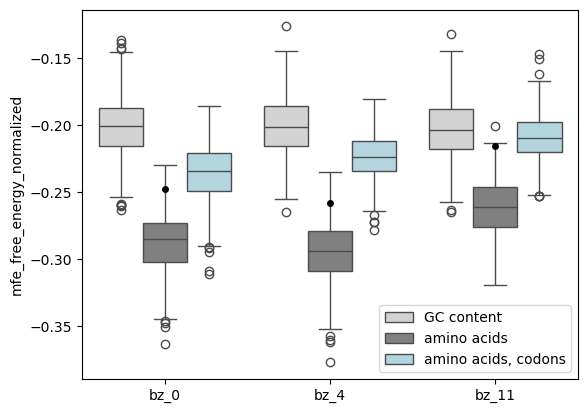

In [23]:

figure_df = rnafold_df[rnafold_df.control].copy() # Get the null distributions.
figure_df['bz_gene_id'] = figure_df.genome_id.map(genes_df.reset_index(names='gene_id').set_index('genome_id').gene_id)
figure_df['bz_gc_content'] = figure_df.bz_gene_id.map(genes_df.gc_content)
figure_df['bz_gc_content_diff'] = np.abs(figure_df.bz_gc_content - figure_df.gc_content)

delta = 0.01
filter_ = (figure_df.codon_usage_control & (figure_df.bz_gc_content_diff < delta))
for genome_id, df in figure_df[filter_].groupby('genome_id'):
    print(f'Number of {genome_id} codon usage-controlled sequences with GC content +/- {delta}:', len(df))


fig, ax = plt.subplots()

metric = 'ensemble_free_energy_normalized'
metric = 'mfe_free_energy_normalized'
# metric = 'ensemble_diversity'
# metric = 'gc_content'

categories = dict()
categories['amino acids'] = figure_df.amino_acid_control & ~figure_df.codon_usage_control
categories['amino acids, codons'] = figure_df.amino_acid_control & figure_df.codon_usage_control
categories['GC content'] = figure_df.gc_content_control.astype(bool) # Sequences explicitly controlling for GC content with no other constraints.

figure_df['category'] = np.select(*list(zip(*categories.items()))[::-1], default='none')

palette = dict()
palette['amino acids'] = 'gray'
palette['amino acids, codons'] = 'lightblue'
palette['amino acids, GC content'] = 'steelblue'
palette['GC content'] = 'lightgray'

sns.boxplot(figure_df, x='genome_id', y=metric, hue='category', palette=palette)
# sns.scatterplot(figure_df[filter_], x='genome_id', y=metric, color='black', s=10)

figure_df = rnafold_df[(~rnafold_df.control)].loc[genes_df.index].copy()
sns.stripplot(figure_df, x='genome_id', y=metric, color='black')

for genome_id, df in figure_df.groupby('genome_id'):
    value = getattr(df.iloc[0], metric)
    # null = rnafold_df[rnafold_df.control & rnafold_df.gc_content_control & (rnafold_df.genome_id == genome_id)][metric].values 
    null = rnafold_df[rnafold_df.control & rnafold_df.codon_usage_control & (rnafold_df.genome_id == genome_id)][metric].values 
    print(f'{genome_id} p={(null < value).mean():.3f} (n={len(null)}, delta={null.mean() - value:.3f})')

ax.set_xlabel('')
plt.show()

# (1) The sequences consistently have higher GC content than the codon frequency-controlled null model. Although this effect is statistically-significant,
#      the magnitude of the difference is fairly small (between 3-5%).
# (2) The sequences generally have slightly lower free energy than the codon usage-controlled null model, though this is only statistically-significant in 
#       bz_11. It is possible that this effect is due to the slightly higher GC content as opposed to any specific secondary structure. 
# (3) In general, the codon usage in the organism results in slightly lower free energy than if GC content was fixed.



In [24]:
# for gene_id in genes_df.index:
#     path = os.path.join(RNAFOLD_DIR, gene_id + '_circular')
#     RNAFoldOutput(path).dotplot()

In [ ]:

# if not os.path.exists('analysis-1-cluster_20-iptms.json'): # These AlphaFold jobs were created using the processed forms of the proteins.
#     iptms = dict()
#     for path in glob.glob('../data/genes/alphafold/af_output/ppi-cluster_20/*'):
#         output = AlphaFoldOutput(path, version=4)
#         iptms[output.name] = output.get_iptms(best_model=True)

#     with open('analysis-1-cluster_20-iptms.json', 'wb') as f:
#         f.write(orjson.dumps(iptms, f))

# else:
#     with open('analysis-1-cluster_20-iptms.json', 'rb') as f:
#         iptms = orjson.loads(f.read())


# figure_df = pd.DataFrame.from_dict(iptms, orient='index', columns=['iptm']).reset_index(names='name')
# figure_df['gene_id_0'] = figure_df.name.str.split('-').str[0]
# figure_df['gene_id_1'] = figure_df.name.str.split('-').str[1]
# figure_df['genome_id'] = figure_df.name.apply(get_genome_id)
# figure_df['cluster_id_0'] = figure_df.gene_id_0.map(json.load(open('../data/genes/clusters.json', 'r')))
# figure_df['cluster_id_1'] = figure_df.gene_id_1.map(json.load(open('../data/genes/clusters.json', 'r')))
# figure_df['contact_id'] = figure_df.apply(get_contact_id, axis=1)
# figure_df['cluster_id'] = [row.cluster_id_0 if (row.cluster_id_0 != 20) else row.cluster_id_1 for row in figure_df.itertuples()]
# figure_df['cluster_id'] = figure_df.cluster_id.astype(str)
# figure_df = figure_df[figure_df.iptm > 0.2].copy().sort_values('iptm', ascending=False)

# fig, ax = plt.subplots(figsize=(4, len(figure_df) * 0.2))

# sns.stripplot(figure_df, y='cluster_id', x='iptm', hue='genome_id', palette=GENOME_ID_COLORS)
# ax.set_ylabel('contact ID')
# ax.set_xlabel('IPTM')
# ax.legend().set_title('')

In [26]:
# Make an AlphaFold input file for the web server for some exploratory analysis on the processed proteins. These were obtained by:
#   (1) N-terminally extending some of the cluster_20 proteins  (those around 80 amino acids in length) to around 95 amino acids.
#   (2) De-replicating the dataset, as some of the sequences differed only in the N-terminal region. 
#   (3) For those with strong signal peptide predictions (all of those with the N-terminal region), obtain the processed sequence using 
#       SignalP, i.e. the protein with the signal peptide cleaved. 


# seq_col = 'seq_processed'
# num_subunits = 2

# inputs = list()
# for path in msa_paths:
#     with open(path, 'r') as f:
#         msa = f.read()
#         print(f'Number of sequences in {path}:', msa.count('>'))

#         gene_id = os.path.basename(path).replace('.a3m', '')
#         input = AlphaFoldInputFile(name=f'{get_genome_id(gene_id)}_cluster_20_{n}mer_processed', num_seeds=1, dialect='alphafoldserver')
#         input.add_seq(database_df.loc[gene_id, seq_col], unpaired_msa=msa, paired_msa="", n=num_subunits)
#         inputs.append(input)

# inputs = [input.get_info() for input in inputs]
# with open('/home/prichter/Downloads/cluster_20.json', 'w') as f:
#     json.dump(inputs, f)


In [27]:
# for path in glob.glob('../data/genes/alphafold/server/*'):
#     if 'cluster_20_2mer' in path:
#         print(path)
#         output = AlphaFoldServerOutput(path)
#         contact_probs = output.get_contact_probs(best_model=True)
#         paes = output.get_paes(best_model=True)

# contact_probs = contact_probs[:70, -70:]
# sns.kdeplot(contact_probs.ravel())
# row_idxs, col_idxs = np.where(contact_probs > 0.5)
# contact_probs



In [28]:
# # Two of the three original cluster_20 proteins have a weak annotation for a prokaryotic lipoprotein attachment site (from InterProScan). 
# # Based on this result, I ran SignalP on each of the original cluster_20 proteins, as well as the ggKbase BLAST hits.

# SIGNALP_FIELDS = ['gene_id', 'prediction', 'other', 'sp_sec_spi', 'lipo_sec_spii', 'tat_tat_spi', 'tatlipo_tat_spii)', 'pilin_sec_spiii', 'cleavage_site_position']
# signalp_df = pd.read_csv('../data/genes/signalp/cluster_20.txt', sep='\t', comment='#', names=SIGNALP_FIELDS)

# if 'prediction' not in ggkbase_df.columns:
#     ggkbase_df = ggkbase_df.merge(signalp_df, on='gene_id', how='left')

# ggkbase_df[['gene_id', 'prediction', 'length', 'sp_sec_spi']]

In [29]:
# for row in genes_df.itertuples():
#     print(f'>{row.Index}')
#     print(row.seq)

In [30]:
# # SR-VP_9_9_2021_59_4A_0_85m_scaffold_34976_2 is Betazoid.
# # Dalian_Groundwater_SRR22387926_scaffold_135972_3 is Betazoid.
# # SR-VP_07_25_2022_A1_70cm_scaffold_29863_3 is a Betazoid.

# # Based on the GC content, it seems as though some of the hits might belong to Borgs?

# # I wonder if the short sequences have mispredicted starts?


# GGKBASE_DIR = '../data/genes/ggkbase/'
# gene_ids = ['Dalian_Groundwater_SRR22387926_scaffold_135972_3', 'SR-VP_07_25_2022_A1_70cm_scaffold_29863_3']

# ggkbase_df = pd.concat([FASTAFile.from_file(os.path.join(GGKBASE_DIR, f'{gene_id}.faa')).to_df() for gene_id in genes_df.index])
# ggkbase_df.index = [gene_id.split('|')[0] for gene_id in ggkbase_df.index] # Clean up the ggKbase gene IDs.
# ggkbase_df = ggkbase_df[~ggkbase_df.index.duplicated(keep='first')].copy()

# ggkbase_df['contig_id'] = ['_'.join(gene_id.split('_')[:-1]) for gene_id in ggkbase_df.index]
# ggkbase_df['start'] = ggkbase_df.description.apply(lambda description : int(description.split('#')[1].strip())) - 1 # Convert to zero-indexed for my sanity. 
# ggkbase_df['stop'] = ggkbase_df.description.apply(lambda description : int(description.split('#')[2].strip()))
# ggkbase_df['strand'] = ggkbase_df.description.apply(lambda description : int(description.split('#')[3].strip()))
# ggkbase_df = ggkbase_df.loc[gene_ids].copy()
# ggkbase_df['contig'] = ggkbase_df.contig_id.apply(lambda contig_id : FASTAFile.from_file(os.path.join(GGKBASE_DIR, f'{contig_id}.fasta')).seqs[0])


# for row in ggkbase_df.itertuples():
#     if row.strand == -1:
#         contig_length = len(row.contig)
#         ggkbase_df.loc[row.Index, 'strand'] = 1
#         ggkbase_df.loc[row.Index, 'start'] = contig_length - row.stop
#         ggkbase_df.loc[row.Index, 'stop'] = contig_length - row.start
#         ggkbase_df.loc[row.Index, 'contig'] = reverse_complement(row.contig)

# ggkbase_df['nt_seq'] = ggkbase_df.apply(lambda row : row.contig[row.start:row.stop], axis=1)
# ggkbase_df['start_codon'] =  ggkbase_df.apply(lambda row : row.contig[row.start:row.start + 3], axis=1)
# ggkbase_df['stop_codon'] =  ggkbase_df.apply(lambda row : row.contig[row.stop - 3:row.stop], axis=1)

# translate = lambda nt_seq : str(Seq(nt_seq).translate(to_stop=False))

# for row in ggkbase_df.itertuples():
#     nt_seq = row.contig[:row.start] # Get the sequence before the start codon. 
#     nt_seq = nt_seq[len(nt_seq) % 3:] # Make sure it's a length divisible by three; shift start position so the sequence is in-frame.
#     codons = np.array([nt_seq[i:i+3] for i in range(0, len(nt_seq), 3)])
#     stop_codon_idx = np.where(np.isin(codons, STOP_CODONS))[0].max()
    
#     nt_seq = ''.join(codons[-30:])
#     print(nt_seq)
#     print(translate(nt_seq), translate(row.contig[row.start:row.stop]))



In [31]:
# GGKBASE_DIR = '../data/genes/ggkbase/'

# query_gene_ids = genes_df.index.tolist()

# paths = [os.path.join('../data/genes', f'{gene_id}.faa') for gene_id in genes_df.index]

# database_df = [genes_df[['seq']].copy()]
# database_df += [FASTAFile.from_file(os.path.join(GGKBASE_DIR, f'{gene_id}.faa')).to_df()[['seq']] for gene_id in genes_df.index]
# database_df = pd.concat(database_df)
# database_df = database_df[database_df.seq.apply(len) < 110].copy() # These all seem to be false positives.
# database_df = database_df.drop_duplicates('seq')
# database_df.index = [gene_id.split('|')[0] for gene_id in database_df.index] # Clean up the ggKbase gene IDs.
# database_df = database_df[database_df.index != 'SR2-18-Sp2_coassembly_scaffold_597830_2'].copy() # Don't really trust this hit. 

# assert np.all(np.isin(query_gene_ids, database_df.index)), 'Some of the query sequences are missing from the database.'
# FASTAFile.from_df(database_df).write('../data/genes/mmseqs/cluster_20_database.faa')

# params = dict()
# # params['min_seq_identity'] = 0.99
# # params['num_iterations'] = 3

# msa_paths = msa_main('../data/genes/mmseqs/cluster_20_database.faa', query_gene_ids=query_gene_ids, database_dir='../data/genes/mmseqs/db/', fmt='a3m', name=f'cluster_20', output_dir='../data/genes/mmseqs', **params)

In [32]:
for row in database_df.itertuples():
    print(f'>{row.Index}')
    print(row.seq)

>orfm.bz_0.1_114
MSNKNKAMVMLLIVAGVFALSASAVSATSCTDAGDFVGICNTVIGIANGTLAVISILFTGNNASIIIEAALIVTIVGAILDLSRGKSSWLRSKFERV
>orfm.bz_11.1_116
MIVSIAFLTLPATATVCSDAGSFNSTCVTITDLGKGIIAVFSVLVTGDNAGVLITTAITIAIVVAVFDLSRGKESYIGRHFRRM
>SR-VP_9_9_2021_59_4A_0_85m_scaffold_34976_2
MHVMRNMSGCLKAIRNKLAVTSIIMAGAISGASATVSTADLGTWASLANLTTQLFLTGLYVVQEILTGDNASTLIYGIIVFAIVMAVLDLRKPDSI
>Dalian_Groundwater_SRR22387926_scaffold_135972_3
MSGQFDSLATLVTDLANATLTVASTIFTGNNAGIVLSAIVVIVLVVLFLRIPDKLYDYLKMR
>orfm.bz_4.1_121
MVNRKYLTVFLIAVGMIVLTASNVGATACSDAGDFEGVCTSLSGLFNATMALISIVATGSNASIIITAAVILAIVTFFVDMARGEKSWLRAKMRNL
>SR-VP_07_25_2022_A1_70cm_scaffold_29863_3
MGQFDTLGTLVTDLANATLTVIGTVFTGDNAGIVLSAVVVIALIVIFMRVPDKIMGKYFRK


In [33]:
msa_paths = msa_main('../data/genes/mmseqs/cluster_20_database.faa', query_gene_ids=query_gene_ids, fmt='afa', name=f'cluster_20', output_dir='../data/genes/muscle')

NameError: name 'query_gene_ids' is not defined

In [ ]:
msa = MSAFile.from_file('../data/genes/muscle/cluster_20.afa')
msa.show()

# The conserved cysteine residue is typical of a lipoprotein
len('KNKAMVMLLIVAGVFALSASAVSATS')

0	MHVMRNMSGCLKAIRNKLAVTSIIMAGAI....SGASATVSTADLGTWASLANLTTQLFLTGLYVVQEILTGDNASTLIYGIIVFAIVMAVLDLRKPDSI.........*	110	SR-VP_9_9_2021_59_4A_0_85m_scaffold_34976_2
0	MVN...........RKY.LTVFLIAVGMIVLTASNVGATA.CSDAGDFEGVCTSLSGLFNATMALISIVATGSNASIIITAAVILAIVTFFVDMARGEKSWLRAKMRN.L	110	orfm.bz_4.1_121
0	MSN...........KNKAMVMLLIVAGVFALSASAVSATS.CTDAGDFVGICNTVIGIANGTLAVISILFTGNNASIIIEAALIVTIVGAILDLSRGKSSWLRSKFER.V	110	orfm.bz_0.1_114
0	M....................LLIVAGVFALSASAVSATS.CTDAGDFVGICNTVIGIANGTLAVISILFTGNNASIIIEAALIVTIVGAILDLSRGKSSWLRSKFERV*	110	SR-VP_11_27_2022_S1_60cm_scaffold_16350_2
0	MIT...........SKKILFSTIMIVSIAFLT.LPATATV.CSDAGSFNSTCVTITDLGKGIIAVFSVLVTGDNAGVLITTAITIAIVVAVFDLSRGKESYIGRHFRR.M	110	orfm.bz_11.1_116
0	M.......................IVSIAFLT.LPATATV.CSDAGSFNSTCVTITDLGKGIIAVFSVLVTGDNAGVLITTAITIAIVVAVFDLSRGKESYIGRHFRRM*	110	SR-VP_9_9_2021_31_2B_1_5m_scaffold_23596_3
0	...........................................MSGQFDSLATLVTDLANATLTVASTIFTGNNAGIVLSAIVVIVLVVLFLRIPDKLYDYLK...MR.*	110	Dal

26

In [ ]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
genes_df[genes_df.cluster_id == 1].strand.value_counts()

strand
-    11
Name: count, dtype: int64

In [ ]:
def get_candidate_cluster_20_genes(start:int, stop:int):

    tmhmm_file = TMHMMFile.from_file('../data/genes/tmhmm/genes.txt')

    genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
    genes_df = genes_df[genes_df.genome_id != 'bz_12'].copy()
    genes_df['gene_id'] = genes_df.index
    genes_df['num_tmhs'] = genes_df.index.map(tmhmm_file.get_num_tmhs())
    genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
    # genes_df = genes_df[].copy()

    filter_ = (genes_df.start > start) & (genes_df.stop < stop)
    filter_ = filter_ & (genes_df.num_tmhs > 0)
    # filter_ = filter_ & ~genes_df.prodigal_gene_id.isnull()
    filter_ = filter_ & (genes_df.strand == '-') # Don't really trust genes on the + strand (not on the primary replichore).
    filter_ = filter_ & (genes_df.seq.apply(len) > 70) &  (genes_df.seq.apply(len) < 110)
    filter_ = filter_ & (~genes_df.cluster_id.isin([4, 5]))
    print('Number of genomes with candidate cluster_20 proteins:', genes_df[filter_].genome_id.nunique(), end='\n\n')

    for genome_id, df in genes_df[filter_].groupby('genome_id'):
        print(genome_id)
        for row in df.itertuples():
            # info = [f'{row.gene_id} / {row.prodigal_gene_id}']
            info = [f'{row.gene_id}']
            info += [f'{int(row.num_tmhs)} TMHs']
            info += [f'cluster_{int(row.cluster_id)}']
            info += [f'Prodigal-predicted? {not pd.isnull(row.prodigal_gene_id)}']
            info += [f'strand {row.strand}']
            info += [f'length {len(row.seq)} aa']
            info += [f'{row.start}-{row.stop}']
            print('\t'.join(info))
        print()

get_candidate_cluster_20_genes(6000, 15000)

# This approach doesn't seem to be working. Is it possible that all of the TMHMM predictions are wrong?

# orfm.bz_10.1_77 Is predicted to be one long helix, despite having two TMH predictions. orfm.bz_10.1_75 is a definite no. 

# orfm.bz_2.1_95 and orfm.bz_2.1_133 both seem to have only two helices.

# orfm.bz_1.1_111 and orfm.bz_1.1_120 are both predicted to be one helix.

# orfm.bz_8.1_147 Looks really likely, orfm.bz_8.1_129 is a maybe, orfm.bz_8.1_176 definitely not.

Number of genomes with candidate cluster_20 proteins: 9

bz_0
orfm.bz_0.1_114	3 TMHs	cluster_20	Prodigal-predicted? True	strand -	length 97 aa	10257-10553

bz_1
orfm.bz_1.1_111	1 TMHs	cluster_1261	Prodigal-predicted? True	strand -	length 83 aa	7058-7321
orfm.bz_1.1_120	1 TMHs	cluster_1255	Prodigal-predicted? False	strand -	length 72 aa	6237-6464

bz_10
orfm.bz_10.1_75	1 TMHs	cluster_348	Prodigal-predicted? True	strand -	length 93 aa	7955-8258
orfm.bz_10.1_77	2 TMHs	cluster_347	Prodigal-predicted? True	strand -	length 89 aa	8287-8563

bz_11
orfm.bz_11.1_70	1 TMHs	cluster_236	Prodigal-predicted? True	strand -	length 74 aa	6525-6753
orfm.bz_11.1_116	2 TMHs	cluster_20	Prodigal-predicted? True	strand -	length 96 aa	11033-11324

bz_2
orfm.bz_2.1_95	2 TMHs	cluster_1159	Prodigal-predicted? True	strand -	length 96 aa	9218-9521
orfm.bz_2.1_133	2 TMHs	cluster_1141	Prodigal-predicted? True	strand -	length 80 aa	12980-13283

bz_4
orfm.bz_4.1_121	2 TMHs	cluster_20	Prodigal-predicted? True	strand -	l

In [ ]:
gene

NameError: name 'gene' is not defined